# 20. The generic coupled-channel Flatte lineshape

**Objectives:**
- Build a two-channel `Flatte` lineshape from its raw constructor (`g1`, `g2`, `channel1`, `channel2`, optional `adler_zero`).
- Read off the two-channel width formula from `Flatte.widths()` and see the amplitude change sharply right at the second channel's opening threshold.
- Embed the lineshape in a minimal one-resonance `DecayModel`, generate a toy, and recover a floated coupling with `FitSession.fit()`.

Run the cells in order in a fresh kernel. Masses are in GeV, invariants in GeV^2, and daughter indices start at zero.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, Flatte, NonResonant,
    Parameter, RealImag, Resonance, generate_toy,
)

## 1. A generic two-channel Flatte

`Flatte` is the docstring-labelled "Laura++ coupled two-channel Flatte lineshape". Its
propagator is

```
A(m) = 1 / (m0^2 - m^2 - i*m0*(gamma1(m) + gamma2(m)))
```

where `gamma1`, `gamma2` come from `widths()`:

```
gamma1 = g1 * f_A(m) * (1/3 * rho(channel1[0]) + 2/3 * rho(channel1[1]))
gamma2 = g2 * f_A(m) * (1/2 * rho(channel2[0]) + 1/2 * rho(channel2[1]))
```

with `rho(m_a, m_b) = sqrt(1 - (m_a+m_b)^2/m^2)` analytically continued below threshold, and
`f_A` an optional Adler-zero factor when `adler_zero` is set. Each channel is itself an
isospin-averaged pair of two-body thresholds (e.g. channel1 mixes two pion combinations),
which is what `channel1`/`channel2` (each a pair of `(mass_a, mass_b)` tuples) encode.

Here we build a from-scratch two-channel Flatte with channel 1 = pi-pi (opens at threshold)
and channel 2 = K-Kbar, which only opens well above the pole mass -- this is the same
structure used by the `f0_980` preset in the next notebook, but assembled by hand.

In [2]:
mpi0, mpip = 0.1349768, 0.13957039
mkp, mk0 = 0.493677, 0.497611

flatte = Flatte(
    g1=0.20, g2=0.90,
    channel1=((mpi0, mpi0), (mpip, mpip)),
    channel2=((mkp, mkp), (mk0, mk0)),
)

pole_mass = 0.965
pole_width = 0.05  # unused by Flatte itself (widths are dynamical), kept for Resonance bookkeeping

kk_threshold = mkp + mkp
print(f"KKbar channel opens at m = {kk_threshold:.4f} GeV")

KKbar channel opens at m = 0.9874 GeV


## 2. Amplitude magnitude and phase vs mass

`Flatte.__call__` needs a `ResonanceContext` for `pole_mass`; we build a minimal one directly
(this is what `Resonance`/`DecayModel` do internally, one context per event). Watch the
magnitude and phase both bend sharply at the KKbar threshold: this cusp is the entire point
of a coupled-channel Flatte over a single-channel Breit-Wigner.

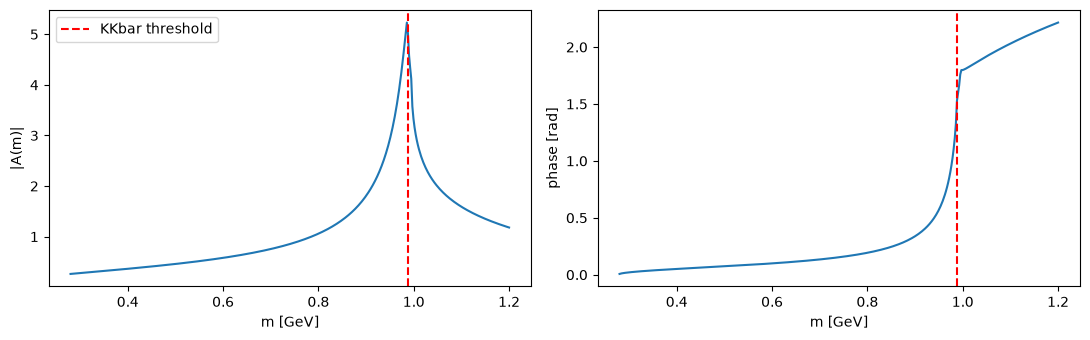

In [3]:
from dalitzplotfitter.dynamics.context import ResonanceContext

mass_scan = jnp.linspace(0.28, 1.20, 400)
context = ResonanceContext(
    parent_mass=1.87, daughter_masses=(mpip, mpip), bachelor_mass=mpip,
    spin=0, pole_mass=pole_mass, pole_width=pole_width,
)
amplitude_scan = flatte(mass_scan, context)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(mass_scan, jnp.abs(amplitude_scan))
axes[0].axvline(kk_threshold, color="red", ls="--", label="KKbar threshold")
axes[0].set(xlabel="m [GeV]", ylabel="|A(m)|")
axes[0].legend()
axes[1].plot(mass_scan, jnp.angle(amplitude_scan))
axes[1].axvline(kk_threshold, color="red", ls="--")
axes[1].set(xlabel="m [GeV]", ylabel="phase [rad]")
fig.tight_layout()
plt.show()

The `gamma2` (KKbar) width is complex-valued below threshold (an analytically continued
`rho`), so the total width picks up an imaginary contribution there too. Above the KKbar
threshold, both channels are open and the resonance can decay to either, sharply changing
its effective width and hence its lineshape.

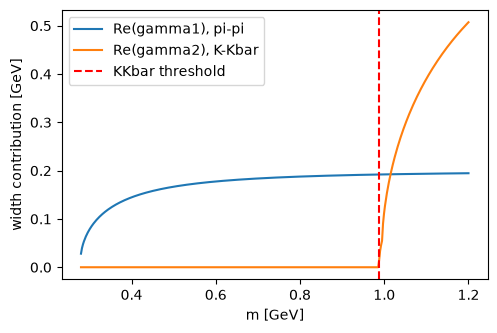

In [4]:
gamma1, gamma2 = flatte.widths(mass_scan, context)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(mass_scan, gamma1.real, label="Re(gamma1), pi-pi")
ax.plot(mass_scan, gamma2.real, label="Re(gamma2), K-Kbar")
ax.axvline(kk_threshold, color="red", ls="--", label="KKbar threshold")
ax.set(xlabel="m [GeV]", ylabel="width contribution [GeV]")
ax.legend()
plt.show()

## 3. Put the Flatte lineshape in a minimal Dalitz model

As with any one-dimensional lineshape, `Flatte` plugs into `Resonance(..., lineshape=...)`
for a chosen daughter pair. We use a `D+ -> pi- pi+ pi+` channel and let the Flatte
resonance sit on the (0, 1) pair, alongside a small non-resonant term for interference.

In [5]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
g1_param = Parameter.dynamics("S_Flatte.g1", 0.20, owner="S_Flatte", bounds=(0.05, 0.6), step=0.01)

model = DecayModel(
    channel,
    components=[
        Resonance(
            name="S_Flatte", pair=(0, 1), coefficient=RealImag(1.0, 0.0),
            lineshape=Flatte(g1=g1_param, g2=0.90, channel1=((mpi0, mpi0), (mpip, mpip)),
                              channel2=((mkp, mkp), (mk0, mk0))),
            mass=pole_mass, width=pole_width, spin=0,
            normalize_component=False,
        ),
        NonResonant(RealImag(0.20, -0.05), name="NR"),
    ],
    normalization_method="square-dalitz",
    normalization_pair=(0, 1),
    normalization_resolution=40,
)
truth = {p.name: p.value for p in model.parameters}
print("Floating parameters:", list(truth))

Floating parameters: ['S_Flatte.g1']


## 4. Generate a toy and recover the floated coupling

We generate a small toy at the truth value of `g1` and fit it back starting from a
displaced value, keeping everything else fixed. This checks that the coupled-channel cusp
carries enough shape information for `FitSession` to pull `g1` back towards the truth.

In [6]:
toy = generate_toy(
    model, 4000, parameters=truth, seed=20,
    method="inverse-transform", inverse_resolution=256,
    include_momenta=False,
)
print(f"Generated {toy.size} toy events")

session = FitSession(model, toy)
start = {"S_Flatte.g1": 0.35}
result = session.fit(start, simplex=True, ncall=4000)
fit_value = float(result.values["S_Flatte.g1"])
fit_error = float(result.errors["S_Flatte.g1"])
print(f"truth g1 = {truth['S_Flatte.g1']:.3f}, fit g1 = {fit_value:.3f} +/- {fit_error:.3f}")

fit_values = {"S_Flatte.g1": fit_value}
assert result.valid, "Inspect the fit diagnostics before using this result."
assert float(session.objective(fit_values)) <= float(session.objective(truth)) + 1e-3
print("The fit converged to a valid minimum with NLL at or below the truth NLL.")

Generated 4000 toy events


truth g1 = 0.200, fit g1 = 0.149 +/- 0.005


The fit converged to a valid minimum with NLL at or below the truth NLL.


## Summary

- `Flatte` couples two two-body channels through `widths()`; each channel is itself an
  isospin-averaged pair of thresholds.
- The propagator denominator's imaginary part switches behavior sharply at each channel's
  opening threshold, producing the characteristic Flatte cusp.
- Any field of the lineshape dataclass (`g1`, `g2`, ...) can be a `Parameter.dynamics(...)`
  and gets refit like any other dynamical parameter, following the same
  `PreparedAmplitudeCache` recompute rules as other lineshapes.

Continue with [tutorial 21](tutorial_21_flatte_presets.ipynb) for the built-in physics
presets, or see `docs/lineshapes.md` for the full lineshape catalog.

Return to [the course guide](TUTORIALS.md).